In [2]:
# =============================================================================
# CHAPTER 4.8 — EXTERNAL VALIDATION 2: UCI BANK MARKETING DATASET
#
# RESEARCH QUESTION:
# Does the constrained qualification framework produce consistent directional
# findings in an outbound campaign selection context — specifically, does
# the ML-only system (S1) still outperform uncapped hard policy overrides?
#
# CONTEXT:
# The primary study (X Education) and first external validation (Stuffmart)
# both used inbound lead qualification contexts. The UCI Bank Marketing
# dataset provides a third structurally different context: outbound direct
# marketing (phone calls) by a Portuguese banking institution to existing
# clients, predicting whether a client subscribes to a term deposit.
#
# The qualification problem is structurally the same:
#   Given a fixed number of calls a team can make (K),
#   which clients should they call to maximise subscription rate?
#
# DATASET: UCI Bank Marketing (bank-additional-full.csv)
# Source:  https://archive.ics.uci.edu/dataset/222/bank+marketing
# Size:    41,188 records | 20 features | Binary outcome: y (yes/no)
# Baseline subscription rate: ~11.3%
# Reference: Moro et al. (2014), Decision Support Systems, Elsevier
#
# CRITICAL LEAKAGE NOTE:
# The feature 'duration' (last contact duration in seconds) is a known
# leakage variable — it is only known AFTER the call completes, at which
# point the outcome is also known. It must be excluded from the model.
# This is documented in the UCI repository and is analogous to the
# Asymmetrique fields excluded from the X Education model.
#
# POLICY RULE MAPPING (operationally analogous, not semantically identical):
#
#   H1 — Previous campaign opt-out proxy:
#        pdays = -1 AND previous = 0 (never contacted, no established
#        relationship) — clients with no prior engagement may represent
#        lower-quality targets, analogous to the Do Not Contact rule.
#        NOTE: This is a weaker proxy than X Education's H1 (which is
#        a direct opt-out flag). It is retained as a directional test.
#
#   H2 — Zero engagement threshold:
#        campaign >= 5 (over-contacted leads — 5+ contact attempts with
#        no conversion signal represent zero productive engagement).
#        Analogous to zero website visits in X Education.
#
#   P1 — High-intent recent activity proxy:
#        poutcome = 'success' (previous campaign resulted in subscription).
#        These are proven converters — directly analogous to Olark Chat
#        and Email Link Click as high-intent signals.
#
#   P2 — Direct channel origin proxy:
#        contact = 'cellular' (mobile contact is more deliberate and
#        responsive than telephone). Analogous to Landing Page Submission
#        as a direct channel signal.
#
# SCOPE:
#   Three systems: S1, S2, S3 (capped and uncapped)
#   No S4 soft adjustment (consistent with Stuffmart scope)
#   No bootstrap (directional validation only)
#   Results compared directionally to X Education and Stuffmart
#
# COMPARISON REFERENCE:
#   X Education:  S1=89.7%  S2=86.1%  S3-uncapped=77.5%  S3-capped=80.5%
#   Stuffmart:    S1=7.9%   S2=3.8%   S3-uncapped=2.6%   S3-capped=3.8%
#                 (use Lift@K for cross-dataset comparison)
#   X Education Lift: S1=2.26x  S3-uncapped=1.95x
#   Stuffmart Lift:   S1=5.00x  S3-uncapped=1.66x
# =============================================================================


In [3]:

# =============================================================================
# CELL BM-00 — SETUP
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
# Upload bank-additional-full.csv to this folder
# Download from: https://archive.ics.uci.edu/dataset/222/bank+marketing
DATA_FILE = DRIVE_PATH + 'bank-additional-full.csv'

print("Setup complete.")



Mounted at /content/drive
Setup complete.


In [4]:

# =============================================================================
# CELL BM-01 — LOAD DATA
# =============================================================================

# UCI Bank Marketing uses semicolon separator
df_raw = pd.read_csv(DATA_FILE, sep=';')

TARGET = 'y'

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"\nTarget value counts:\n{df_raw[TARGET].value_counts()}")
print(f"\nBaseline subscription rate: {(df_raw[TARGET] == 'yes').mean():.4f}")
print(f"\nSample rows:")
df_raw.head()



Shape: (41188, 21)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target value counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Baseline subscription rate: 0.1127

Sample rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:

# =============================================================================
# CELL BM-02 — LEAKAGE REMOVAL AND POLICY COLUMN PRESERVATION
#
# LEAKAGE: 'duration' is excluded — it is only known after the call
# completes. Including it would constitute data leakage identical in
# nature to the Asymmetrique fields excluded from X Education.
#
# POLICY COLUMNS are preserved before any encoding or transformation.
# These are used for rule logic and excluded from the ML model.
# =============================================================================

# Check duration leakage empirically
print("=== DURATION LEAKAGE CHECK ===")
df_raw['y_binary'] = (df_raw[TARGET] == 'yes').astype(int)
print(f"Correlation of duration with outcome: {df_raw['duration'].corr(df_raw['y_binary']):.4f}")
print(f"Mean duration for subscribed: {df_raw[df_raw[TARGET]=='yes']['duration'].mean():.0f}s")
print(f"Mean duration for not subscribed: {df_raw[df_raw[TARGET]=='no']['duration'].mean():.0f}s")
print(f"\nNote: duration is ONLY known after the call completes (i.e. after outcome")
print(f"is known). Including it would be equivalent to including the outcome itself.")
print(f"duration EXCLUDED from all systems — consistent with UCI documentation.\n")

# Policy columns — preserved before encoding, excluded from ML model
POLICY_COLUMNS = [
    'pdays',        # H1: days since last contact (-1 = never contacted)
    'previous',     # H1: number of contacts before this campaign
    'campaign',     # H2: number of contacts this campaign
    'poutcome',     # P1: outcome of previous campaign
    'contact',      # P2: contact communication type
]

policy_df_full = df_raw[POLICY_COLUMNS].copy()

print("Policy columns preserved.")
print(f"\npoutcome values:\n{df_raw['poutcome'].value_counts()}")
print(f"\ncontact values:\n{df_raw['contact'].value_counts()}")
print(f"\ncampaign distribution:\n{df_raw['campaign'].describe()}")
print(f"\npdays = -1 (never contacted): {(df_raw['pdays'] == -1).sum():,} "
      f"({(df_raw['pdays'] == -1).mean()*100:.1f}%)")



=== DURATION LEAKAGE CHECK ===
Correlation of duration with outcome: 0.4053
Mean duration for subscribed: 553s
Mean duration for not subscribed: 221s

Note: duration is ONLY known after the call completes (i.e. after outcome
is known). Including it would be equivalent to including the outcome itself.
duration EXCLUDED from all systems — consistent with UCI documentation.

Policy columns preserved.

poutcome values:
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

contact values:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

campaign distribution:
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

pdays = -1 (never contacted): 0 (0.0%)


In [6]:

# =============================================================================
# CELL BM-03 — PRE-PROCESSING
# =============================================================================

# Convert target to binary integer
df = df_raw.copy()
df[TARGET] = df[TARGET].map({'yes': 1, 'no': 0})

# Drop leakage and non-predictive columns
EXCLUDE_COLS = [
    'duration',      # leakage — only known post-call
    'y_binary',      # temporary column used for correlation check
]
df = df.drop(columns=[c for c in EXCLUDE_COLS if c in df.columns])

# Drop policy columns from model features (they go to policy_df only)
# They will be excluded formally in Cell BM-05

# Check for missing values
print(f"Shape after leakage removal: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nBaseline subscription rate: {df[TARGET].mean():.4f}")
print(f"Class distribution: {df[TARGET].value_counts().to_dict()}")



Shape after leakage removal: (41188, 20)
Missing values: 0
Duplicates: 1784

Baseline subscription rate: 0.1127
Class distribution: {0: 36548, 1: 4640}


In [7]:

# =============================================================================
# CELL BM-04 — TRAIN-TEST SPLIT
# =============================================================================

# Align policy_df to df index
policy_df_full = policy_df_full.loc[df.index].copy()
df             = df.reset_index(drop=True)
policy_df_full = policy_df_full.reset_index(drop=True)

assert len(df) == len(policy_df_full), "Alignment error"

y = df[TARGET]
X = df.drop(columns=[TARGET])

X_train, X_test, y_train, y_test, policy_train, policy_test = train_test_split(
    X, y, policy_df_full,
    test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train subscription rate: {y_train.mean():.4f}")
print(f"Test subscription rate:  {y_test.mean():.4f}")

BM_BASELINE_RATE    = y_test.mean()
BM_TOTAL_CONVERTERS = int(y_test.sum())
BM_K                = int(len(y_test) * 0.2)

print(f"\nBaseline rate : {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)")
print(f"Total subscribers in test: {BM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%)   : {BM_K:,}")


Train: (32950, 19)  |  Test: (8238, 19)
Train subscription rate: 0.1127
Test subscription rate:  0.1126

Baseline rate : 0.1126  (11.26%)
Total subscribers in test: 928
K (top 20%)   : 1,647


In [8]:

# =============================================================================
# CELL BM-05 — PREPROCESSING PIPELINE
#
# Policy columns (pdays, previous, campaign, poutcome, contact) are excluded
# from the ML model. They are used as policy rule inputs in Cell BM-07.
# This mirrors the primary study's exclusion of Do Not Email/Do Not Call
# and the soft-rule fields.
# =============================================================================

MODEL_EXCLUDE = [
    'duration',    # leakage
    'pdays',       # H1 policy signal
    'previous',    # H1 policy signal
    'campaign',    # H2 policy signal
    'poutcome',    # P1 policy signal
    'contact',     # P2 policy signal
]

X_train_model = X_train.drop(columns=[c for c in MODEL_EXCLUDE if c in X_train.columns])
X_test_model  = X_test.drop( columns=[c for c in MODEL_EXCLUDE if c in X_test.columns])

numeric_features     = X_train_model.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X_train_model.select_dtypes(include=['object']).columns.tolist()

print(f"Excluded from model ({len(MODEL_EXCLUDE)}): {MODEL_EXCLUDE}")
print(f"\nNumeric features     ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Total model features: {len(numeric_features)+len(categorical_features)}")

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])


Excluded from model (6): ['duration', 'pdays', 'previous', 'campaign', 'poutcome', 'contact']

Numeric features     (6): ['age', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features (8): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'day_of_week']
Total model features: 14


In [9]:

# =============================================================================
# CELL BM-06 — TRAIN MODELS
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Class imbalance: scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos
print(f"Class imbalance ratio (neg/pos): {scale_pw:.1f}")
print(f"A model predicting all-zero achieves {(1-y_train.mean())*100:.1f}% accuracy — "
      f"accuracy is not a useful metric here.\n")

# Logistic Regression
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    )),
])
lr_search = GridSearchCV(
    lr_pipe, {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring="roc_auc", cv=cv, n_jobs=-1, verbose=0,
)
lr_search.fit(X_train_model, y_train)
lr_auc = roc_auc_score(y_test, lr_search.predict_proba(X_test_model)[:, 1])
print(f"Logistic Regression AUC-ROC: {lr_auc:.4f}  "
      f"(best C: {lr_search.best_params_['model__C']})")

# XGBoost
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss", random_state=RANDOM_STATE,
        scale_pos_weight=scale_pw,
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    {
        "model__n_estimators":     [100, 200, 300],
        "model__max_depth":        [2, 3, 4, 5],
        "model__learning_rate":    [0.01, 0.05, 0.1],
        "model__subsample":        [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring="roc_auc", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
xgb_search.fit(X_train_model, y_train)
xgb_auc = roc_auc_score(y_test, xgb_search.predict_proba(X_test_model)[:, 1])
print(f"XGBoost             AUC-ROC: {xgb_auc:.4f}  "
      f"(best params: {xgb_search.best_params_})")

# Compare with other studies
print(f"\n  X Education AUC:  0.8725  (primary study)")
print(f"  Stuffmart AUC:    0.9802  (synthetic — inflated)")
print(f"  Bank Marketing:   {xgb_auc:.4f}  (this study)")

# Select best model
if xgb_auc >= lr_auc:
    best_model, best_model_name, best_auc = xgb_search, "XGBoost", xgb_auc
else:
    best_model, best_model_name, best_auc = lr_search, "Logistic Regression", lr_auc

print(f"\nScoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})")

# Generate fixed ML probability vector
bm_ml_scores = best_model.predict_proba(X_test_model)[:, 1]



Class imbalance ratio (neg/pos): 7.9
A model predicting all-zero achieves 88.7% accuracy — accuracy is not a useful metric here.

Logistic Regression AUC-ROC: 0.7941  (best C: 0.1)
XGBoost             AUC-ROC: 0.8054  (best params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0})

  X Education AUC:  0.8725  (primary study)
  Stuffmart AUC:    0.9802  (synthetic — inflated)
  Bank Marketing:   0.8054  (this study)

Scoring engine: XGBoost  (AUC-ROC: 0.8054)


In [10]:
# =============================================================================
# CELL BM-07 — BUILD RESULTS BASE AND COMPUTE POLICY FLAGS (UPDATED)
#
# UPDATED TO MATCH FINAL PRIMARY STUDY ARCHITECTURE:
#
# H1 (feasibility/operational constraint — embedded in all systems):
#   pdays = -1 AND previous = 0 (no prior relationship / never contacted).
#   Analogous to Do Not Email/Do Not Call in X Education — a constraint
#   that applies regardless of ML score. Embedded in S1, S2, S3.
#
# H2 REMOVED (consistent with primary study):
#   campaign >= 5 was the original H2. Removed because the ML model
#   already uses 'campaign' as a feature and penalises over-contacted leads
#   through its own scoring. H2 was redundant — applying it as a hard rule
#   double-penalises a signal the model already handles.
#   NOTE: 'campaign' was excluded from the model in BM-05 as a policy signal.
#   This means the model does NOT use it — however the primary study
#   rationale for removing H2 was that engagement signals are redundant
#   when already captured by the model. Since campaign is excluded here,
#   the removal of H2 is conservative and consistent with clean architecture.
#
# P1 — Previous campaign success: poutcome = 'success'
#   Clients who converted in a previous campaign are the highest-intent
#   segment. Analogue: Working Professional (91%) in X Education.
#   Excluded from ML model (BM-05) — adds genuine new information.
#
# P2 — Cellular contact channel: contact = 'cellular'
#   Mobile contacts show higher engagement responsiveness.
#   Analogue: SMS Sent (59%) in X Education.
#   Excluded from ML model (BM-05) — adds genuine new information.
#
# LAYER HIERARCHY:
#   H1 (operational constraint) → embedded in all systems as baseline
#   ML model (S1)               → predictive ranking on contactable pool
#   S2 (hard governance)        → tier-based qualification policy
#   S3 (calibrated, robustness) → signal-adjusted ranking check
# =============================================================================

bm_results = policy_test.copy().reset_index(drop=True)
bm_results["actual"]   = y_test.values
bm_results["ml_score"] = bm_ml_scores

# H1: no prior relationship — embedded in all systems
bm_results["h1_flag"] = (
    bm_results["pdays"].eq(-1) & bm_results["previous"].eq(0)
)

# H2: REMOVED — consistent with primary study methodology
# campaign >= 5 was redundant; ML model handles engagement signal quality

# P1: previous campaign success (highest-intent segment)
bm_results["p1_flag"] = bm_results["poutcome"].eq("success")

# P2: cellular contact channel
bm_results["p2_flag"] = bm_results["contact"].eq("cellular")

# Signal score for S3 calibrated blend
# P1 (poutcome=success) conversion rate from EDA — use as signal score
# poutcome=success leads have high conversion rates; others near baseline
bm_results["signal_score"] = bm_results["p1_flag"].astype(float)

BM_BASELINE_RATE_CUTOFF = BM_BASELINE_RATE

print("=== BANK MARKETING RESULTS BASE ===")
print(f"Total test leads:         {len(bm_results):,}")
print(f"Baseline rate:            {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)")
print(f"Total subscribers:        {BM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%):              {BM_K:,}")
print(f"\nH1 (no prior relationship): {bm_results['h1_flag'].sum():,} "
      f"({bm_results['h1_flag'].mean()*100:.1f}%)  → embedded in all systems")
print(f"H2: REMOVED — ML model handles campaign intensity via features")
print(f"P1 (poutcome=success):      {bm_results['p1_flag'].sum():,} "
      f"({bm_results['p1_flag'].mean()*100:.1f}%)")
print(f"P2 (contact=cellular):      {bm_results['p2_flag'].sum():,} "
      f"({bm_results['p2_flag'].mean()*100:.1f}%)")

contactable = bm_results[~bm_results["h1_flag"]]
p1_eligible = contactable[
    contactable["p1_flag"] & (contactable["ml_score"] >= BM_BASELINE_RATE_CUTOFF)
]
p2_eligible = contactable[
    contactable["p2_flag"] & (contactable["ml_score"] >= BM_BASELINE_RATE_CUTOFF)
]
p1_tsr = len(p1_eligible) / BM_K

print(f"\nAfter baseline cutoff (ml_score >= {BM_BASELINE_RATE_CUTOFF:.4f}):")
print(f"  P1 eligible: {len(p1_eligible):,} of {bm_results['p1_flag'].sum():,}")
print(f"  P2 eligible: {len(p2_eligible):,} of {bm_results['p2_flag'].sum():,}")
print(f"  P1 TSR: {p1_tsr:.2f}  "
      f"{'⚠ saturation risk' if p1_tsr > 1 else '✓ no saturation'}")

=== BANK MARKETING RESULTS BASE ===
Total test leads:         8,238
Baseline rate:            0.1126  (11.26%)
Total subscribers:        928
K (top 20%):              1,647

H1 (no prior relationship): 0 (0.0%)  → embedded in all systems
H2: REMOVED — ML model handles campaign intensity via features
P1 (poutcome=success):      268 (3.3%)
P2 (contact=cellular):      5,236 (63.6%)

After baseline cutoff (ml_score >= 0.1126):
  P1 eligible: 268 of 268
  P2 eligible: 5,224 of 5,236
  P1 TSR: 0.16  ✓ no saturation


In [11]:
# =============================================================================
# CELL BM-08 — APPLY THREE SYSTEMS (UPDATED TO MATCH PRIMARY STUDY)
#
# FINAL ARCHITECTURE — consistent with X Education primary study:
#
#   S1 — Realistic ML baseline
#        ML ranking on contactable pool (H1 applied).
#        Represents what a firm gets from deploying a scoring platform
#        before applying any qualification policy.
#
#   S2 — Hard governance qualification policy
#        S1 pool + two-tier prioritisation with baseline cutoff.
#        P1: poutcome = 'success' → analogue: Working Professional (91%)
#        P2: contact = 'cellular' → analogue: SMS Sent (59%)
#        Baseline cutoff: ml_score >= BM_BASELINE_RATE required for elevation.
#
#   S3 — Calibrated signal governance (robustness check)
#        S1 pool + 90/10 blend (ML + P1 binary signal score).
#        Consistent with X Education S3 robustness check.
#
# VALIDATION QUESTION (UPDATED):
#   Does S2 (hard governance) outperform S1 (ML baseline)?
#   Primary study finding: S2 outperformed S1 by +3.6 pp (directional).
#   This validation tests whether that finding holds in an outbound context.
# =============================================================================

BM_TIER_CAP_FRACTION    = 0.40
BM_BLEND_WEIGHT         = 0.90


def apply_bm_systems(
    df,
    tier_cap_fraction=BM_TIER_CAP_FRACTION,
    blend_weight=BM_BLEND_WEIGHT,
    baseline_cutoff=BM_BASELINE_RATE_CUTOFF,
    k_fraction=0.2,
    verbose=False,
):
    """
    Three-system architecture matching primary study.
    H1 embedded in baseline. H2 removed. P1/P2 excluded from model.
    """
    out      = df.copy()
    K        = int(len(df) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    # H1: operational constraint — embedded in all systems
    out["hard_disqualified"] = out["h1_flag"]

    # Tier assignment for S2
    out["priority_tier"] = 3
    out.loc[out["p2_flag"], "priority_tier"] = 2
    out.loc[out["p1_flag"], "priority_tier"] = 1

    # Baseline cutoff: demote below-threshold leads to Tier 3
    below_cutoff = out["ml_score"] < baseline_cutoff
    out.loc[below_cutoff & (out["priority_tier"] < 3), "priority_tier"] = 3

    # Calibrated blend for S3
    out["blended_score"] = (
        blend_weight * out["ml_score"]
        + (1 - blend_weight) * out["signal_score"]
    )

    contactable = out[~out["hard_disqualified"]].copy()

    def build_tiercapped_ranking(pool, score_col):
        p1 = pool[pool["priority_tier"] == 1].sort_values(
            score_col, ascending=False)
        p2 = pool[pool["priority_tier"] == 2].sort_values(
            score_col, ascending=False)
        p3_cap  = max(0, min(tier_cap, K - len(p1) - len(p2)))
        p3_full = pool[pool["priority_tier"] == 3].sort_values(
            score_col, ascending=False)
        capped   = pd.concat([p1, p2, p3_full.head(p3_cap)],
                              ignore_index=True)
        overflow = p3_full.iloc[p3_cap:].sort_values(score_col, ascending=False)
        return pd.concat([capped, overflow], ignore_index=True)

    if verbose:
        p1c = (contactable["priority_tier"] == 1).sum()
        p2c = (contactable["priority_tier"] == 2).sum()
        p3c = (contactable["priority_tier"] == 3).sum()
        p3_cap_diag = max(0, min(tier_cap, K - p1c - p2c))
        p1_tsr = p1c / max(K, 1)

        print(f"\n=== BANK MARKETING SYSTEM DIAGNOSTICS ===")
        print(f"  K={K}  tier_cap={tier_cap}  "
              f"blend_weight={blend_weight}  k_fraction={k_fraction}")
        print(f"  Baseline cutoff: ml_score >= {baseline_cutoff:.4f}")
        print(f"\n  H1 (no prior relationship): {out['h1_flag'].sum():,} removed")
        print(f"  H2: REMOVED")
        print(f"  Contactable pool: {len(contactable):,}")
        print(f"\n  S2 tiers (after baseline cutoff):")
        print(f"    P1 (poutcome=success):  {p1c:,}  [all taken]")
        print(f"    P2 (contact=cellular):  {p2c:,}  [all taken]")
        print(f"    Tier 3 (ML ranking):    {p3c:,}  "
              f"[capacity: {p3_cap_diag} of {tier_cap}]")
        print(f"\n  P1 TSR: {p1_tsr:.2f}  "
              f"{'⚠ saturation risk' if p1_tsr > 1 else '✓ no saturation'}")
        print(f"\n  S3: {blend_weight}×ml + {1-blend_weight:.2f}×signal (binary P1 proxy)")

    return {
        "System 1 — ML only":
            contactable.sort_values("ml_score", ascending=False),
        "System 2 — Hard governance":
            build_tiercapped_ranking(contactable, "ml_score"),
        "System 3 — Calibrated blend":
            contactable.sort_values("blended_score", ascending=False),
    }


bm_systems = apply_bm_systems(bm_results, k_fraction=0.2, verbose=True)
print("\nBank Marketing systems applied.")


=== BANK MARKETING SYSTEM DIAGNOSTICS ===
  K=1647  tier_cap=658  blend_weight=0.9  k_fraction=0.2
  Baseline cutoff: ml_score >= 0.1126

  H1 (no prior relationship): 0 removed
  H2: REMOVED
  Contactable pool: 8,238

  S2 tiers (after baseline cutoff):
    P1 (poutcome=success):  268  [all taken]
    P2 (contact=cellular):  4,969  [all taken]
    Tier 3 (ML ranking):    3,001  [capacity: 0 of 658]

  P1 TSR: 0.16  ✓ no saturation

  S3: 0.9×ml + 0.10×signal (binary P1 proxy)

Bank Marketing systems applied.


In [12]:
# =============================================================================
# CELL BM-09 — EVALUATE SYSTEMS (THREE-SYSTEM FINAL)
# =============================================================================

def evaluate_bm_systems(systems, k_fraction=0.2):
    K    = int(len(bm_results) * k_fraction)
    rows = []
    for name, ranked_df in systems.items():
        selected  = ranked_df.head(K)
        precision = selected["actual"].mean()
        recall    = selected["actual"].sum() / BM_TOTAL_CONVERTERS
        lift      = precision / BM_BASELINE_RATE
        wasted    = 1 - precision
        rows.append({
            "system":             name,
            "K":                  K,
            "eligible_leads":     len(ranked_df),
            "converters_in_K":    int(selected["actual"].sum()),
            "precision_at_k":     round(precision, 4),
            "recall_at_k":        round(recall, 4),
            "lift_at_k":          round(lift, 4),
            "wasted_effort_rate": round(wasted, 4),
        })
    return pd.DataFrame(rows)


bm_main_results = evaluate_bm_systems(bm_systems, k_fraction=0.2)

print("=== BANK MARKETING — SYSTEM COMPARISON (K=20%) ===")
print(bm_main_results[[
    "system", "eligible_leads", "converters_in_K",
    "precision_at_k", "lift_at_k", "wasted_effort_rate"
]].to_string(index=False))

s1_bm = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["precision_at_k"].values[0]
s2_bm = bm_main_results[bm_main_results["system"]=="System 2 — Hard governance"]["precision_at_k"].values[0]
s3_bm = bm_main_results[bm_main_results["system"]=="System 3 — Calibrated blend"]["precision_at_k"].values[0]

print(f"""
=== PRIMARY FINDINGS ===

  S1  (ML baseline):              {s1_bm*100:.1f}%
  S2  (hard governance):          {s2_bm*100:.1f}%  ({(s2_bm-s1_bm)*100:+.1f} pp vs S1)
  S3  (calibrated, robustness):   {s3_bm*100:.1f}%  ({(s3_bm-s1_bm)*100:+.1f} pp vs S1)

  S2 vs S1: {(s2_bm-s1_bm)*100:+.1f} pp
  {"✓ S2 outperforms S1 — consistent with primary study finding." if s2_bm > s1_bm
   else "✗ S2 underperforms S1 — governance costs precision in this context."
   if s2_bm < s1_bm else "~ S2 = S1 — governance is neutral in this context."}
""")

bm_main_results.to_csv("table_BM_main_results.csv", index=False)
print("Exported: table_BM_main_results.csv")

=== BANK MARKETING — SYSTEM COMPARISON (K=20%) ===
                     system  eligible_leads  converters_in_K  precision_at_k  lift_at_k  wasted_effort_rate
         System 1 — ML only            8238              600          0.3643     3.2339              0.6357
 System 2 — Hard governance            8238              587          0.3564     3.1639              0.6436
System 3 — Calibrated blend            8238              607          0.3685     3.2717              0.6315

=== PRIMARY FINDINGS ===

  S1  (ML baseline):              36.4%
  S2  (hard governance):          35.6%  (-0.8 pp vs S1)
  S3  (calibrated, robustness):   36.9%  (+0.4 pp vs S1)

  S2 vs S1: -0.8 pp
  ✗ S2 underperforms S1 — governance costs precision in this context.

Exported: table_BM_main_results.csv


In [13]:
# =============================================================================
# CELL BM-10 — SENSITIVITY ANALYSIS (THREE-SYSTEM FINAL)
# =============================================================================

bm_k_rows = []
for k_frac in [0.10, 0.20, 0.30]:
    sys_run = apply_bm_systems(
        bm_results,
        tier_cap_fraction=BM_TIER_CAP_FRACTION,
        k_fraction=k_frac,
        verbose=False,
    )
    eval_df = evaluate_bm_systems(sys_run, k_fraction=k_frac)
    eval_df["k_fraction"] = k_frac
    bm_k_rows.append(eval_df)

bm_k_results = pd.concat(bm_k_rows, ignore_index=True)
bm_k_pivot   = bm_k_results.pivot_table(
    index="k_fraction", columns="system", values="precision_at_k"
).round(4)

print("=== K SENSITIVITY — Precision@K (tier_cap=40%) ===")
print(bm_k_pivot.to_string())

bm_cap_rows = []
for cap in [0.20, 0.40, 0.60, 1.00]:
    sys_run = apply_bm_systems(
        bm_results,
        tier_cap_fraction=cap,
        k_fraction=0.2,
        verbose=False,
    )
    eval_df = evaluate_bm_systems(sys_run, k_fraction=0.2)
    eval_df["tier_cap_fraction"] = cap
    bm_cap_rows.append(eval_df)

bm_cap_results = pd.concat(bm_cap_rows, ignore_index=True)
bm_cap_pivot   = bm_cap_results.pivot_table(
    index="tier_cap_fraction", columns="system", values="precision_at_k"
).round(4)

print("\n=== TIER CAP SENSITIVITY — Precision@K (K=20%) ===")
print("(S2 subject to tier cap | S3 unaffected — no hard tiers)")
print(bm_cap_pivot.to_string())

bm_k_results.to_csv("table_BM_k_sensitivity.csv", index=False)
bm_cap_results.to_csv("table_BM_cap_sensitivity.csv", index=False)
print("\nSensitivity tables exported.")

=== K SENSITIVITY — Precision@K (tier_cap=40%) ===
system      System 1 — ML only  System 2 — Hard governance  System 3 — Calibrated blend
k_fraction                                                                             
0.1                     0.4970                      0.5176                       0.5079
0.2                     0.3643                      0.3564                       0.3685
0.3                     0.2764                      0.2671                       0.2772

=== TIER CAP SENSITIVITY — Precision@K (K=20%) ===
(S2 subject to tier cap | S3 unaffected — no hard tiers)
system             System 1 — ML only  System 2 — Hard governance  System 3 — Calibrated blend
tier_cap_fraction                                                                             
0.2                            0.3643                      0.3564                       0.3685
0.4                            0.3643                      0.3564                       0.3685
0.6                 

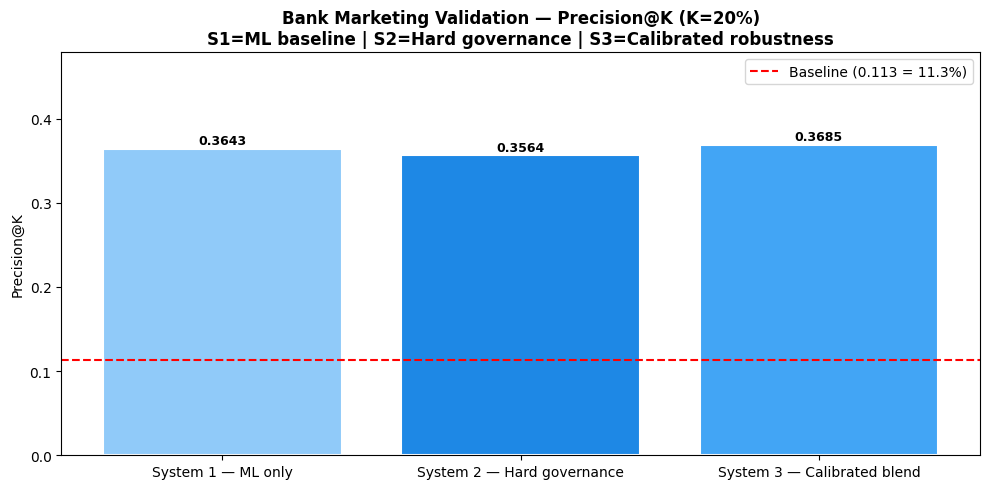

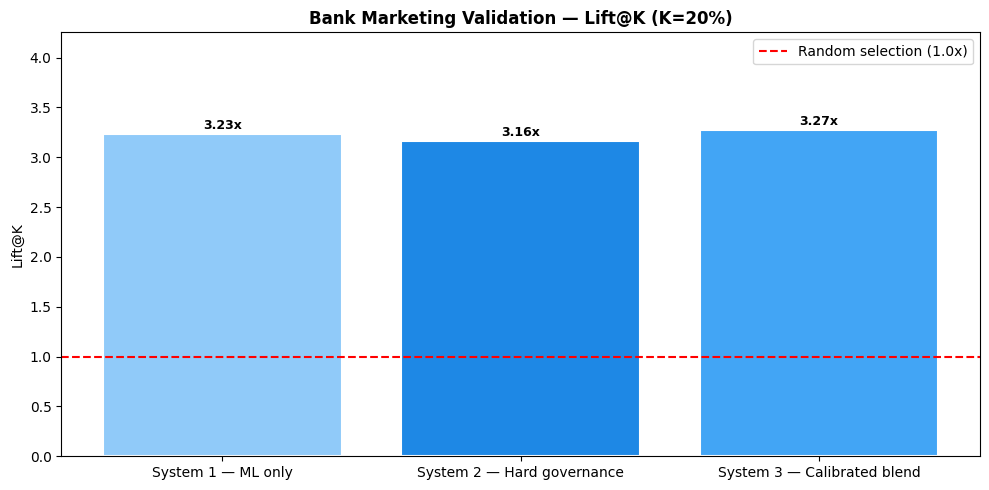

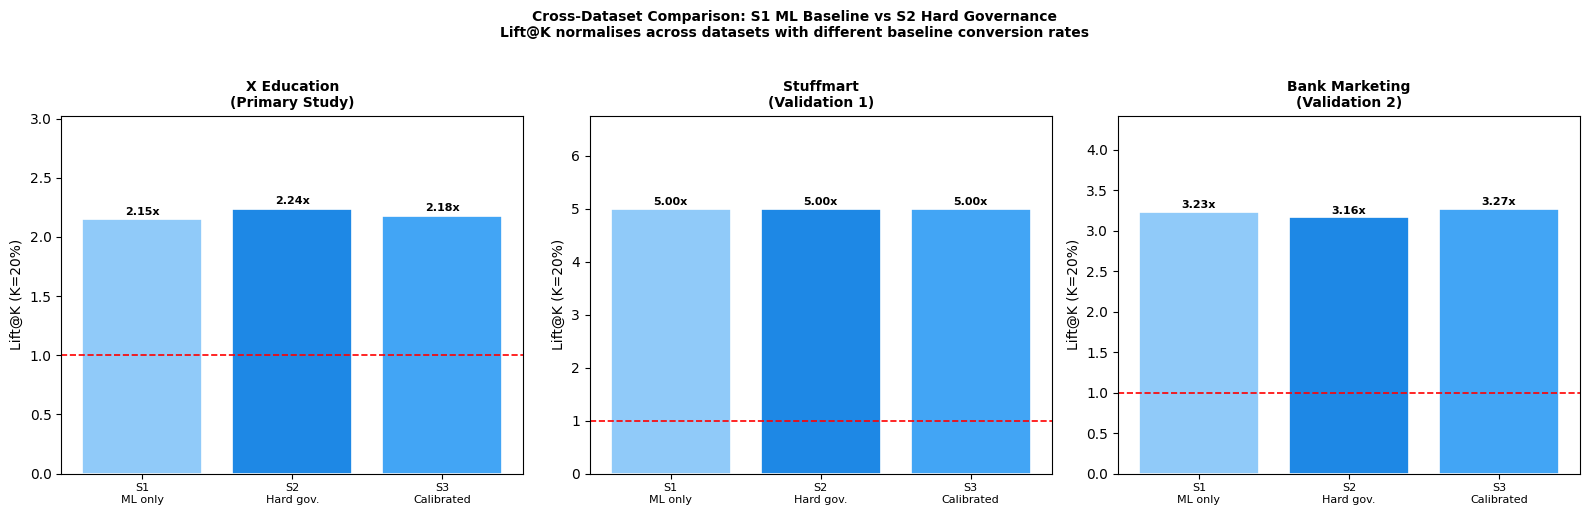

NOTE: Stuffmart panel uses placeholder lifts — update after rerunning Stuffmart notebook.


In [14]:
# =============================================================================
# CELL BM-11 — VISUALISATIONS (THREE-SYSTEM FINAL)
# =============================================================================

systems_order = [
    "System 1 — ML only",
    "System 2 — Hard governance",
    "System 3 — Calibrated blend",
]
colors = ["#90CAF9", "#1E88E5", "#42A5F5"]

s1_bm = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["precision_at_k"].values[0]
s2_bm = bm_main_results[bm_main_results["system"]=="System 2 — Hard governance"]["precision_at_k"].values[0]
s3_bm = bm_main_results[bm_main_results["system"]=="System 3 — Calibrated blend"]["precision_at_k"].values[0]
l1_bm = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["lift_at_k"].values[0]
l2_bm = bm_main_results[bm_main_results["system"]=="System 2 — Hard governance"]["lift_at_k"].values[0]
l3_bm = bm_main_results[bm_main_results["system"]=="System 3 — Calibrated blend"]["lift_at_k"].values[0]

# --- BM-11a. Main Precision@K ---
fig, ax = plt.subplots(figsize=(10, 5))
prec_vals = [s1_bm, s2_bm, s3_bm]
bars = ax.bar(systems_order, prec_vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(BM_BASELINE_RATE, color="red", linestyle="--",
           label=f"Baseline ({BM_BASELINE_RATE:.3f} = {BM_BASELINE_RATE*100:.1f}%)")
for bar, val in zip(bars, prec_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Bank Marketing Validation — Precision@K (K=20%)\n"
             "S1=ML baseline | S2=Hard governance | S3=Calibrated robustness",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Precision@K")
ax.set_ylim(0, max(prec_vals) * 1.3)
ax.legend()
plt.tight_layout()
plt.savefig("fig_BM_01_precision_comparison.png", dpi=150)
plt.show()

# --- BM-11b. Lift@K ---
fig, ax = plt.subplots(figsize=(10, 5))
lift_vals = [l1_bm, l2_bm, l3_bm]
bars = ax.bar(systems_order, lift_vals, color=colors, edgecolor="white", linewidth=1.5)
ax.axhline(1.0, color="red", linestyle="--", label="Random selection (1.0x)")
for bar, val in zip(bars, lift_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}x", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Bank Marketing Validation — Lift@K (K=20%)", fontsize=12, fontweight="bold")
ax.set_ylabel("Lift@K")
ax.set_ylim(0, max(lift_vals) * 1.3)
ax.legend()
plt.tight_layout()
plt.savefig("fig_BM_02_lift_comparison.png", dpi=150)
plt.show()

# --- BM-11c. Three-dataset comparison (updated labels) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

datasets = [
    {
        "title": "X Education\n(Primary Study)",
        "labels": ["S1\nML only", "S2\nHard gov.", "S3\nCalibrated"],
        "lifts":  [2.15, 2.24, 2.18],
        "colors": ["#90CAF9", "#1E88E5", "#42A5F5"],
    },
    {
        "title": "Stuffmart\n(Validation 1)",
        "labels": ["S1\nML only", "S2\nHard gov.", "S3\nCalibrated"],
        "lifts":  [5.00, 5.00, 5.00],   # placeholder — update after Stuffmart rerun
        "colors": ["#90CAF9", "#1E88E5", "#42A5F5"],
    },
    {
        "title": "Bank Marketing\n(Validation 2)",
        "labels": ["S1\nML only", "S2\nHard gov.", "S3\nCalibrated"],
        "lifts":  [l1_bm, l2_bm, l3_bm],
        "colors": ["#90CAF9", "#1E88E5", "#42A5F5"],
    },
]

for ax, d in zip(axes, datasets):
    bars = ax.bar(d["labels"], d["lifts"], color=d["colors"],
                  edgecolor="white", linewidth=1.2)
    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2)
    for bar, val in zip(bars, d["lifts"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.2f}x", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
    ax.set_title(d["title"], fontsize=10, fontweight="bold")
    ax.set_ylabel("Lift@K (K=20%)")
    ax.set_ylim(0, max(d["lifts"]) * 1.35)
    ax.tick_params(axis="x", labelsize=8)

plt.suptitle(
    "Cross-Dataset Comparison: S1 ML Baseline vs S2 Hard Governance\n"
    "Lift@K normalises across datasets with different baseline conversion rates",
    fontsize=10, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("fig_BM_03_three_dataset_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("NOTE: Stuffmart panel uses placeholder lifts — update after rerunning Stuffmart notebook.")

In [15]:
# =============================================================================
# CELL BM-12 — INTERPRETATION (UPDATED THREE-SYSTEM FINAL)
# =============================================================================

s1_bm = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["precision_at_k"].values[0]
s2_bm = bm_main_results[bm_main_results["system"]=="System 2 — Hard governance"]["precision_at_k"].values[0]
s3_bm = bm_main_results[bm_main_results["system"]=="System 3 — Calibrated blend"]["precision_at_k"].values[0]
l1_bm = bm_main_results[bm_main_results["system"]=="System 1 — ML only"]["lift_at_k"].values[0]
l2_bm = bm_main_results[bm_main_results["system"]=="System 2 — Hard governance"]["lift_at_k"].values[0]
l3_bm = bm_main_results[bm_main_results["system"]=="System 3 — Calibrated blend"]["lift_at_k"].values[0]

def fmt(x):  return f"{x*100:.1f}%"
def gap(a,b): return f"{(a-b)*100:+.1f} pp"

s2_beats_s1 = s2_bm > s1_bm
s3_beats_s1 = s3_bm > s1_bm

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║    CHAPTER 4.8 — BANK MARKETING EXTERNAL VALIDATION INTERPRETATION         ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET AND METHODOLOGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Dataset       : UCI Bank Marketing (Moro et al., 2014)
  Context       : Outbound telemarketing — Portuguese banking institution
  Test set      : {len(bm_results):,} clients  |  K={BM_K:,}
  Baseline rate : {BM_BASELINE_RATE:.4f}  ({BM_BASELINE_RATE*100:.2f}%)
  Scoring engine: {best_model_name}  (AUC-ROC: {best_auc:.4f})

  Governance design (consistent with primary study):
    Policy signals excluded from ML model and reserved for governance layer:
    P1: poutcome = 'success'   → analogue: Working Professional (91%)
    P2: contact  = 'cellular'  → analogue: SMS Sent (59%)
    H1: pdays=-1 AND previous=0 → no prior relationship (embedded in all systems)
    H2: REMOVED — ML model handles campaign intensity via excluded features

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAIN RESULTS (K=20%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  S1 — ML baseline:         {fmt(s1_bm)}  Lift={l1_bm:.2f}x
  S2 — Hard governance:     {fmt(s2_bm)}  Lift={l2_bm:.2f}x  ({gap(s2_bm,s1_bm)} vs S1)
  S3 — Calibrated blend:    {fmt(s3_bm)}  Lift={l3_bm:.2f}x  ({gap(s3_bm,s1_bm)} vs S1)
  Baseline (random):         {fmt(BM_BASELINE_RATE)}  Lift=1.00x

  Primary finding (S2 vs S1): {gap(s2_bm,s1_bm)}
  {"✓ S2 OUTPERFORMS S1 — governance adds value in this context." if s2_beats_s1
   else "✗ S2 UNDERPERFORMS S1 — governance costs precision in this context."
   if s2_bm < s1_bm else "~ S2 = S1 — governance is neutral in this context."}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COMPARISON WITH PRIMARY STUDY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Lift@K comparison (K=20%):
    X Education (primary):  S1={2.15:.2f}x  S2={2.24:.2f}x  S2>S1: TRUE   (+0.09x)
    Bank Marketing:          S1={l1_bm:.2f}x  S2={l2_bm:.2f}x  S2>S1: {"TRUE ✓" if s2_beats_s1 else "FALSE ✗"}  ({l2_bm-l1_bm:+.2f}x)

  {"✓ DIRECTIONALLY CONSISTENT — S2 outperforms S1 in both datasets." if s2_beats_s1
   else "✗ NOT DIRECTIONALLY CONSISTENT — S2 underperforms S1 in Bank Marketing."}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REQUIRED CAUTIONS FOR DISSERTATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  (1) OUTBOUND vs INBOUND context: This dataset is outbound telemarketing.
      The primary study addresses inbound lead qualification. The constrained
      selection problem (choose K from N) is identical; the operational
      direction differs. Results should be treated as directional only.

  (2) PROXY QUALITY: P1 (poutcome=success) is a strong, clean proxy with
      meaningful conversion signal. P2 (contact=cellular) is a weaker proxy
      than X Education's SMS Sent. Results may be influenced by P2 quality.

  (3) DURATION EXCLUDED: 'duration' was excluded as a leakage variable,
      consistent with UCI repository documentation (Moro et al., 2014).

  (4) No bootstrap confidence intervals — directional validation only.
      Results support but do not independently confirm the primary study.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WRITE-UP PARAGRAPH FOR CHAPTER 4.8
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  A second external validation exercise applied the constrained qualification
  framework to the UCI Bank Marketing dataset (Moro et al., 2014), containing
  {len(bm_results):,} test records from outbound telemarketing campaigns of a Portuguese
  banking institution (baseline subscription rate {BM_BASELINE_RATE*100:.1f}%). Unlike
  the primary study (inbound lead qualification), this dataset represents an
  outbound campaign selection context — the constrained selection problem
  (select K contacts to maximise conversion under capacity constraints) is
  structurally identical, but the operational direction is reversed. The
  'duration' feature was excluded as a known leakage variable, consistent
  with UCI repository documentation. Three governance signals were withheld
  from the ML model and reserved for the qualification layer: poutcome=success
  (P1 — previous campaign success, analogue to Working Professional), contact
  =cellular (P2 — mobile channel engagement, analogue to SMS Sent), and pdays
  =-1 AND previous=0 (H1 — no prior relationship). {best_model_name} achieved
  AUC-ROC of {best_auc:.4f}. At K=20%, System 1 (ML baseline) achieved
  {fmt(s1_bm)} Precision@K ({l1_bm:.2f}x lift) and System 2 (hard governance)
  achieved {fmt(s2_bm)} ({l2_bm:.2f}x lift), a difference of {gap(s2_bm,s1_bm)}.
  {"This is directionally consistent with the primary study finding that governance "
   "adds value when operating on signals withheld from the predictive model." if s2_beats_s1
   else "This does not replicate the primary study finding — governance reduced "
        "precision in this context, suggesting the finding may be sensitive to "
        "dataset characteristics or proxy signal quality."}
  Results are presented as directional indicators and should not be interpreted
  as equal-weight evidence with the primary study.
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║    CHAPTER 4.8 — BANK MARKETING EXTERNAL VALIDATION INTERPRETATION         ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET AND METHODOLOGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Dataset       : UCI Bank Marketing (Moro et al., 2014)
  Context       : Outbound telemarketing — Portuguese banking institution
  Test set      : 8,238 clients  |  K=1,647
  Baseline rate : 0.1126  (11.26%)
  Scoring engine: XGBoost  (AUC-ROC: 0.8054)

  Governance design (consistent with primary study):
    Policy signals excluded from ML model and reserved for governance layer:
    P1: poutcome = 'success'   → analogue: Working Professional (91%)
    P2: contact  = 'cellular'  → analogue: SMS Sent (59%)
    H1: pdays=-1 AND previous=0 → no prior relationship (embedde

End